15:59:13 - cmdstanpy - INFO - Chain [1] start processing
15:59:13 - cmdstanpy - INFO - Chain [1] done processing
15:59:13 - cmdstanpy - INFO - Chain [1] start processing
15:59:13 - cmdstanpy - INFO - Chain [1] done processing
15:59:20 - cmdstanpy - INFO - Chain [1] start processing
15:59:20 - cmdstanpy - INFO - Chain [1] done processing
15:59:20 - cmdstanpy - INFO - Chain [1] start processing



=== Sonuç Özeti ===
Split     Exog Model   MAE  RMSE  MAPE
 TEST  PROPHET    RF 34.85 41.48 25.12
 TEST  PROPHET   XGB 55.39 67.22 34.18
 TEST   SARIMA    RF 75.34 89.76 42.71
 TEST      ETS    RF 67.04 77.31 42.81
 TEST      ETS   XGB 70.33 79.65 44.47
 TEST   SARIMA   XGB 79.29 92.66 45.36
  VAL (direct)   XGB  0.02  0.02  0.01
  VAL (direct)    RF  4.29  5.07  3.38


15:59:20 - cmdstanpy - INFO - Chain [1] done processing
15:59:28 - cmdstanpy - INFO - Chain [1] start processing
15:59:28 - cmdstanpy - INFO - Chain [1] done processing
15:59:28 - cmdstanpy - INFO - Chain [1] start processing
15:59:28 - cmdstanpy - INFO - Chain [1] done processing


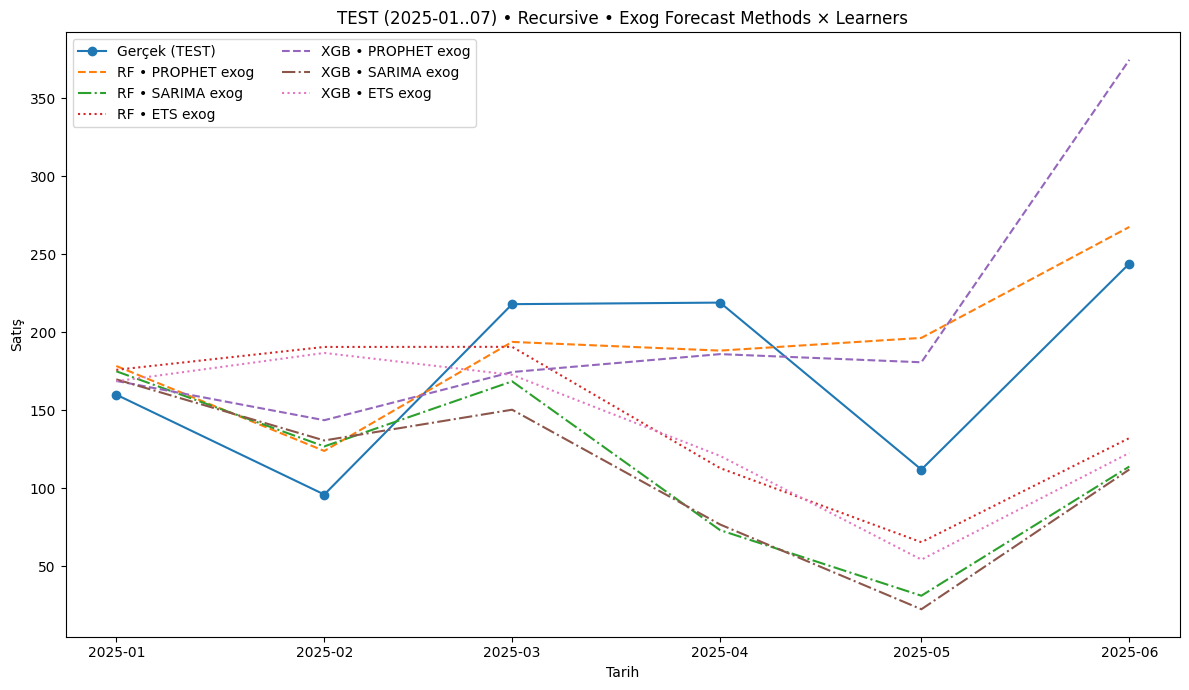

In [5]:
# ==============================================================
# Auto-Exog Forecast (Prophet / SARIMA / ETS) + RF & XGB Comparison
# Features: orders, stock, orders_lag1/3, stock_lag1/3, y_lag1, orders_ratio, month, year
# Missing value imputation: 3-month centered rolling mean (+ffill/bfill fallback)
# Recursive TEST forecast (2025-01..07) with exog forecasts
# ==============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------ Config ------------------
CSV_PATH   = "veri_matrisi_final_sales_orders_stock_calendar_lags_fx.csv"

TRAIN_END  = pd.Timestamp("2024-12-01")
#TRAIN_END  = pd.Timestamp("2025-07-01")
#VAL_START  = pd.Timestamp("2024-07-01")
#VAL_END    = pd.Timestamp("2024-12-01")
VAL_START  = pd.Timestamp("2025-01-01")
VAL_END    = pd.Timestamp("2025-06-01")
TEST_START = pd.Timestamp("2025-01-01")
TEST_END   = pd.Timestamp("2025-06-01")

RANDOM_STATE = 42

FEATURES = [
    "orders","stock",
    "orders_lag1","orders_lag3",
    "stock_lag1","stock_lag3",
    "y_lag1",
    "orders_ratio",
    "month","year",
]

# ------------------ Helpers ------------------
def mae_rmse_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    denom = np.where(y_true == 0, 1, y_true)
    mape = np.mean(np.abs((y_true - y_pred) / denom)) * 100
    return mae, rmse, mape

def ensure_ms_freq(df):
    d = df.copy().sort_values("ds")
    d["ds"] = d["ds"].dt.to_period("M").dt.to_timestamp(how="start")
    d = d.set_index("ds").sort_index()
    d.index = pd.DatetimeIndex(d.index, freq="MS")
    return d.reset_index()

def add_calendar(df):
    d = df.copy()
    d["year"]  = d["ds"].dt.year
    d["month"] = d["ds"].dt.month
    return d

def rolling_impute_3m(s: pd.Series) -> pd.Series:
    """3 aylık merkezli rolling ortalama ile imputasyon; gerekirse ffill/bfill fallback."""
    x = s.copy()
    roll = x.rolling(window=3, center=True, min_periods=1).mean()
    x = x.where(~x.isna(), roll)
    x = x.ffill().bfill()
    return x

def build_lags_minimal(df):
    d = df.copy()
    # ratio
    if "orders" in d.columns and "stock" in d.columns:
        ratio = d["orders"] / d["stock"].replace(0, np.nan)
        d["orders_ratio"] = ratio
    # y lag1
    if "y" in d.columns:
        d["y_lag1"] = d["y"].shift(1)
    # orders lags
    if "orders" in d.columns:
        d["orders_lag1"] = d["orders"].shift(1)
        d["orders_lag3"] = d["orders"].shift(3)
    # stock lags
    if "stock" in d.columns:
        d["stock_lag1"] = d["stock"].shift(1)
        d["stock_lag3"] = d["stock"].shift(3)
    return d

def prep_features(df_in):
    d = add_calendar(df_in)
    d = build_lags_minimal(d)
    # NaN/Inf → impute/clean
    for col in ["orders","stock"]:
        if col in d.columns:
            d[col] = rolling_impute_3m(pd.to_numeric(d[col], errors="coerce"))
    # lags & ratio da NaN olabilir: makul doldurma
    for col in ["orders_lag1","orders_lag3","stock_lag1","stock_lag3","y_lag1","orders_ratio"]:
        if col in d.columns:
            d[col] = d[col].astype(float)
            d[col] = d[col].fillna(method="ffill").fillna(method="bfill").fillna(0)
    # olmayan feature oluşsun (0)
    for c in FEATURES:
        if c not in d.columns:
            d[c] = 0.0
    d = d.replace([np.inf, -np.inf], np.nan).fillna(0)
    return d

# ------------------ Univariate exog forecasters ------------------
def forecast_univariate(df_col: pd.DataFrame, value_col: str, future_idx, method="prophet"):
    """
    df_col: ['ds', value_col], aylık (MS)
    method: 'prophet' | 'sarima' | 'ets'
    """
    s = df_col[["ds", value_col]].dropna().sort_values("ds").copy()
    if s.empty:
        return pd.DataFrame({"ds": future_idx, value_col: 0.0})
    if method == "prophet":
        m = Prophet(yearly_seasonality=True, weekly_seasonality=False)
        m.fit(s.rename(columns={value_col:"y"}))
        last_known = s["ds"].max()
        horizon = max(0, (max(future_idx) - last_known).days // 30 + 1)
        fut = m.make_future_dataframe(periods=horizon, freq="MS")
        fc = m.predict(fut)[["ds","yhat"]]
        out = fc[fc["ds"].isin(pd.DatetimeIndex(future_idx))].copy()
        out = out.rename(columns={"yhat": value_col})
        if out.empty:
            out = pd.DataFrame({"ds": future_idx, value_col: s[value_col].iloc[-1]})
        return out[["ds", value_col]]

    elif method == "sarima":
        y = s.set_index("ds")[value_col]
        y.index.freq = "MS"
        # küçük bir grid
        best, best_aic = None, np.inf
        for p in [0,1,2]:
            for q in [0,1,2]:
                for P in [0,1]:
                    for Q in [0,1]:
                        order = (p,1,q)
                        sorder = (P,1,Q,12)
                        try:
                            res = SARIMAX(y, order=order, seasonal_order=sorder,
                                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                            if res.aic < best_aic:
                                best_aic = res.aic
                                best = (order, sorder)
                        except Exception:
                            pass
        if best is None:
            # fallback ETS
            method = "ets"
        else:
            model = SARIMAX(y, order=best[0], seasonal_order=best[1],
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
            steps = len(future_idx)
            pred = model.get_forecast(steps=steps).predicted_mean
            return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), value_col: pred.values})

    if method == "ets":
        y = s.set_index("ds")[value_col]
        y.index.freq = "MS"
        try:
            ets = ExponentialSmoothing(y, trend="add", seasonal="add", seasonal_periods=12).fit(optimized=True)
        except Exception:
            # no seasonal fallbacks
            ets = ExponentialSmoothing(y, trend="add", seasonal=None).fit(optimized=True)
        steps = len(future_idx)
        pred = ets.forecast(steps)
        return pd.DataFrame({"ds": pd.DatetimeIndex(future_idx), value_col: pred.values})

def build_future_exog(df_all, future_idx, method="prophet"):
    out = pd.DataFrame({"ds": future_idx})
    for col in ["orders","stock"]:
        if col in df_all.columns:
            fc = forecast_univariate(df_all[["ds", col]], col, future_idx, method=method)
            out = out.merge(fc, on="ds", how="left")
        else:
            out[col] = 0.0
    # İmpute exog forecasts da aynı mantıkla
    for c in ["orders","stock"]:
        out[c] = rolling_impute_3m(out[c].astype(float))
    return out

# ------------------ Recursive forward with given learner ------------------
def recursive_forward_predict(model, x_cols, hist_df, future_exog, start_ds, end_ds):
    """
    model: RF or XGB (fit edilmiş)
    x_cols: FEATURES list
    hist_df: geçmiş gerçek (ds,y,orders,stock,month,year) + gerekirse başka sütunlar
    future_exog: (ds, orders, stock) — TEST aralığı için
    """
    future_idx = pd.date_range(start_ds, end_ds, freq="MS")
    future_part = pd.DataFrame({"ds": future_idx}).merge(future_exog, on="ds", how="left")
    full = pd.concat([hist_df, future_part], ignore_index=True).sort_values("ds")

    preds = []
    for ds in future_idx:
        # Özellikleri her adımda yeniden hazırla (lags & ratio & calendar & impute)
        tmp = prep_features(full.copy())
        row = tmp.loc[tmp["ds"] == ds].copy()
        X = row[x_cols].replace([np.inf, -np.inf], np.nan).fillna(0).to_numpy()
        y_hat = model.predict(X)[0]
        preds.append({"ds": ds, "yhat": y_hat})
        # bir sonraki ay için y_lag1 üretimi amacıyla tahmini yaz
        full.loc[full["ds"] == ds, "y"] = y_hat
        # exog yineleme güvenliği
        for c in ["orders","stock"]:
            if c in full.columns:
                full[c] = rolling_impute_3m(full[c].astype(float))

    return pd.DataFrame(preds), full[full["ds"].isin(future_idx)].copy()

# ------------------ Load & prepare ------------------
df = pd.read_csv(CSV_PATH, parse_dates=["ds"]).sort_values("ds").reset_index(drop=True)
for c in ["y","orders","stock"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = ensure_ms_freq(df)
df = prep_features(df)

# Splits
mask_train_full = (df["ds"] <= TRAIN_END)
mask_val        = (df["ds"] >= VAL_START) & (df["ds"] <= VAL_END)
mask_test       = (df["ds"] >= TEST_START) & (df["ds"] <= TEST_END)

train_full = df.loc[mask_train_full].copy()
val_df     = df.loc[mask_val].copy()
test_df    = df.loc[mask_test].copy()

# ------------------ Learners ------------------
def fit_rf(train_df):
    model = RandomForestRegressor(
        n_estimators=500, max_depth=10, min_samples_split=2,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(train_df[FEATURES], train_df["y"])
    return model

def fit_xgb(train_df):
    model = XGBRegressor(
        n_estimators=500, learning_rate=0.08, max_depth=3,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.5,
        random_state=RANDOM_STATE
    )
    model.fit(train_df[FEATURES].to_numpy(), train_df["y"].to_numpy())
    return model

# Train
rf_model  = fit_rf(train_full)
xgb_model = fit_xgb(train_full)

# VAL direct metrics
def eval_direct(model, name):
    y_hat = model.predict(val_df[FEATURES])
    mae, rmse, mape = mae_rmse_mape(val_df["y"], y_hat)
    return {"Split":"VAL", "Exog":"(direct)", "Model":name, "MAE":mae, "RMSE":rmse, "MAPE":mape}

results = []
results.append(eval_direct(rf_model,  "RF"))
results.append(eval_direct(xgb_model, "XGB"))

# ------------------ TEST recursive with exog-forecast methods ------------------
future_idx = pd.date_range(TEST_START, TEST_END, freq="MS")

hist_min = df[df["ds"] < TEST_START][["ds","y","orders","stock","month","year"]].copy()

for exog_method in ["prophet","sarima","ets"]:
    future_exog = build_future_exog(df, future_idx, method=exog_method)

    # RF
    pred_rf, used_rf = recursive_forward_predict(
        rf_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END
    )
    eval_rf = test_df[["ds","y"]].merge(pred_rf, on="ds", how="left")
    mae, rmse, mape = mae_rmse_mape(eval_rf["y"], eval_rf["yhat"])
    results.append({"Split":"TEST", "Exog":exog_method.upper(), "Model":"RF", "MAE":mae, "RMSE":rmse, "MAPE":mape})

    # XGB
    pred_xgb, used_xgb = recursive_forward_predict(
        xgb_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END
    )
    eval_xgb = test_df[["ds","y"]].merge(pred_xgb, on="ds", how="left")
    mae, rmse, mape = mae_rmse_mape(eval_xgb["y"], eval_xgb["yhat"])
    results.append({"Split":"TEST", "Exog":exog_method.upper(), "Model":"XGB", "MAE":mae, "RMSE":rmse, "MAPE":mape})

res_df = pd.DataFrame(results).sort_values(["Split","MAPE"]).reset_index(drop=True)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
print("\n=== Sonuç Özeti ===")
print(res_df.to_string(index=False))

# ------------------ Plot — TEST kıyas ------------------
plt.figure(figsize=(12,7))
plt.plot(test_df["ds"], test_df["y"], "o-", label="Gerçek (TEST)")
colors = {"prophet":"--", "sarima":"-.", "ets":":"}

# RF
for ex in ["prophet","sarima","ets"]:
    future_exog = build_future_exog(df, future_idx, method=ex)
    pred_rf, _ = recursive_forward_predict(rf_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END)
    plt.plot(pred_rf["ds"], pred_rf["yhat"], colors[ex], label=f"RF • {ex.upper()} exog")

# XGB
for ex in ["prophet","sarima","ets"]:
    future_exog = build_future_exog(df, future_idx, method=ex)
    pred_xgb, _ = recursive_forward_predict(xgb_model, FEATURES, hist_min.copy(), future_exog, TEST_START, TEST_END)
    plt.plot(pred_xgb["ds"], pred_xgb["yhat"], colors[ex], label=f"XGB • {ex.upper()} exog")

plt.title("TEST (2025-01..07) • Recursive • Exog Forecast Methods × Learners")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(ncol=2); plt.tight_layout()
plt.show()
